<a href="https://colab.research.google.com/github/ijimekko/e-commerce-sales-analysis/blob/main/E_commerce_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Portfolio Project 1 - E-commerce Sales Analysis

## Project Overview

This portfolio project analyzes e-commerce sales data using **SQL, Python, and Tableau**.

### Objectives

The main objectives of the project are to:

* **Use SQL** to extract and prepare an analytical dataset from a database.
* **Use Python** to perform exploratory and statistical analysis of e-commerce sales data.
* **Use Tableau** to build interactive dashboards and visualize key findings.

The analysis focuses on identifying sales patterns and relationships across different **regions, product categories, devices, traffic channels, and customer groups**, as well as analyzing sales dynamics over time and testing statistically significant differences between selected groups.

## 1. Connecting to Google BigQuery

In [ ]:
!pip install -q --upgrade google-cloud-bigquery

In [ ]:
from google.colab import auth

from google.cloud import bigquery

import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import (
    pearsonr,
    chi2_contingency,
    friedmanchisquare,
    mannwhitneyu,
    shapiro,
    ttest_rel
)

from statsmodels.stats.proportion import proportions_ztest

In [ ]:
auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")

## 2. Creating the Analytical Dataset

In [ ]:
query = """
SELECT
  s.date AS session_date,
  s.ga_session_id AS session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name AS device_model,
  sp.operating_system,
  sp.language AS browser_language,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,
  acs.account_id AS user_id,
  a.is_verified AS email_verified,
  a.is_unsubscribed AS newsletter_unsubscribed,
  p.category AS product_category,
  p.name AS product_name,
  p.price,
  p.short_description AS product_description
FROM `data-analytics-mate.DA.session` AS s
LEFT JOIN `data-analytics-mate.DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
  ON acs.account_id = a.id
LEFT JOIN `data-analytics-mate.DA.order` AS o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
  ON o.item_id = p.item_id;
"""

In [ ]:
df = client.query(query).to_dataframe(create_bqstorage_client=False)

df.head()

,session_date,session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,user_id,email_verified,newsletter_unsubscribed,product_category,product_name,price,product_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
print(f"Total number of columns: {df.shape[1]}.")

Total number of columns: 18.


## 3. Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   session_date             349545 non-null  dbdate 
 1   session_id               349545 non-null  Int64  
 2   continent                349545 non-null  object 
 3   country                  349545 non-null  object 
 4   device                   349545 non-null  object 
 5   browser                  349545 non-null  object 
 6   device_model             349545 non-null  object 
 7   operating_system         349545 non-null  object 
 8   browser_language         235279 non-null  object 
 9   traffic_source           349545 non-null  object 
 10  traffic_channel          349545 non-null  object 
 11  user_id                  27945 non-null   Int64  
 12  email_verified           27945 non-null   Int64  
 13  newsletter_unsubscribed  27945 non-null   Int64  
 14  prod

In [ ]:
numeric_columns = df.select_dtypes(include="number").columns

print(f"Number of numeric columns: {len(numeric_columns)}")
print("Numeric columns:")
print(list(numeric_columns))

Number of numeric columns: 5
Numeric columns:
['session_id', 'user_id', 'email_verified', 'newsletter_unsubscribed', 'price']


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

print(f"Number of categorical (text) columns: {len(categorical_columns)}")
print("Categorical (text) columns:")
print(list(categorical_columns))

Number of categorical (text) columns: 12
Categorical (text) columns:
['continent', 'country', 'device', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'product_description']


In [ ]:
date_columns = ["session_date"]

print(f"Number of date/time columns: {len(date_columns)}")
print("Date/time columns:")
print(date_columns)

Number of date/time columns: 1
Date/time columns:
['session_date']


In [ ]:
print(f"Number of unique sessions: {df["session_id"].nunique()}.")

Number of unique sessions: 349545.


In [ ]:
print(f"Starting date: {df["session_date"].min()}, final date: {df["session_date"].max()}")

Starting date: 2020-11-01, final date: 2021-01-31


In [ ]:
dataset_summary = pd.DataFrame({
    'rows': [df.shape[0]],
    'columns': [df.shape[1]],
    'unique_sessions': [df['session_id'].nunique()],
    'start_date': [df['session_date'].min()],
    'end_date': [df['session_date'].max()]
}).style.hide(axis='index')

dataset_summary

rows,columns,unique_sessions,start_date,end_date
349545,18,349545,2020-11-01,2021-01-31


In [ ]:
missing_values = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_values = missing_values.sort_values(
    "missing_count",
    ascending=False
)

print("Number of missing values in each column:")

missing_values

Number of missing values in each column:


,missing_count,missing_percent
newsletter_unsubscribed,321600,92.005321
email_verified,321600,92.005321
user_id,321600,92.005321
product_description,316007,90.405241
product_name,316007,90.405241
product_category,316007,90.405241
price,316007,90.405241
browser_language,114266,32.689925
session_id,0,0.000000
session_date,0,0.000000


The largest number of missing values is observed in columns related to registered users and products. Missing values in **user_id**, **email_verified**, and **newsletter_unsubscribed** are explained by the fact that a significant proportion of sessions belong to unregistered users. Missing values in **product_category**, **product_name**, **price**, and **product_description** are related to the fact that not every session resulted in an order.

The **browser_language** column also contains missing values, but the exact reason for these missing values requires additional investigation of the source data.

In [ ]:
print("Number of unique values in each column:")
df.nunique()

Number of unique values in each column:


,0
session_date,92
session_id,349545
continent,6
country,108
device,3
browser,6
device_model,10
operating_system,6
browser_language,9
traffic_source,5


## 4. Sales Analysis

### 4.1 Top 3 continents / Top 5 countries

In [ ]:
continent_sales = (
    df.dropna(subset=["price"])
      .groupby("continent")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count"),
          avg_order_value=("price", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

top_3_continents = continent_sales.head(3)

print("Top 3 continents:")

top_3_continents

Top 3 continents:


,total_sales,order_count,avg_order_value
continent,,,
Americas,17665280.0,18553,952.152213
Asia,7601298.3,7950,956.138151
Europe,5934624.2,6261,947.871618


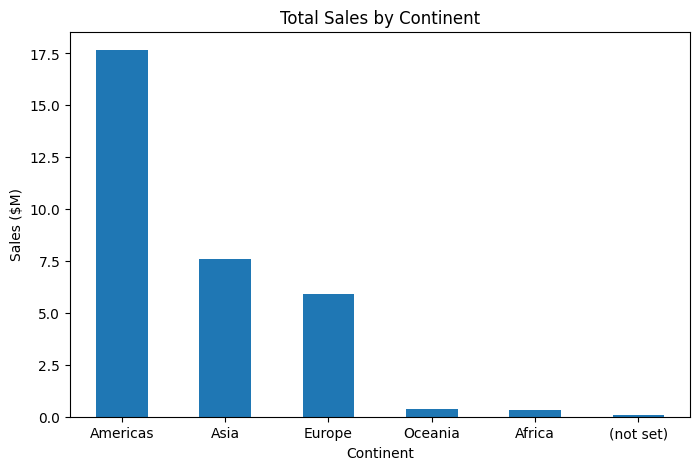

In [ ]:
continent_sales_m = continent_sales['total_sales'] / 1000000

plt.figure(figsize=(8, 5))
continent_sales_m.plot(kind='bar')

plt.title('Total Sales by Continent')
plt.xlabel('Continent')
plt.ylabel('Sales ($M)')
plt.xticks(rotation=0)

plt.show()

In [ ]:
country_sales = (
    df.dropna(subset=["price"])
      .groupby("country")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count"),
          avg_order_value=("price", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

top_5_countries = country_sales.head(5)

print("Top 5 countries:")

top_5_countries

Top 5 countries:


,total_sales,order_count,avg_order_value
country,,,
United States,13943553.9,14673,950.286506
India,2809762.0,3029,927.620337
Canada,2437921.0,2560,952.312891
United Kingdom,938317.9,1029,911.873567
France,710692.8,678,1048.219469


The *Americas* generated the highest total sales (17.67M), followed by *Asia* (7.60M) and *Europe* (5.93M). The difference in total sales is mainly driven by the number of orders, as the average order value is relatively similar across all three continents, ranging from 947.87 to 956.14.

The *United States* was the largest individual market, generating 13.94M in sales from 14,673 orders. *France* had the highest average order value among the top five countries (1,048.22), despite having the lowest number of orders within this group.

### 4.2 Top 10 product categories

In [ ]:
category_sales = (
    df.dropna(subset=["price"])
      .groupby("product_category")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count"),
          avg_order_value=("price", "mean")
      )
      .sort_values("total_sales", ascending=False)
)

top_10_categories = category_sales.head(10)

print("Top 10 categories:")

top_10_categories

Top 10 categories:


,total_sales,order_count,avg_order_value
product_category,,,
Sofas & armchairs,8388254.5,4301,1950.303302
Chairs,6147748.8,5952,1032.887903
Beds,4919725.0,2926,1681.382433
Bookcases & shelving units,3640818.1,7630,477.171442
Cabinets & cupboards,2336499.5,2318,1007.980802
Outdoor furniture,2142222.2,2229,961.068730
Tables & desks,1790307.5,2941,608.741074
Chests of drawers & drawer units,906562.5,1452,624.354339
Bar furniture,735503.0,1092,673.537546


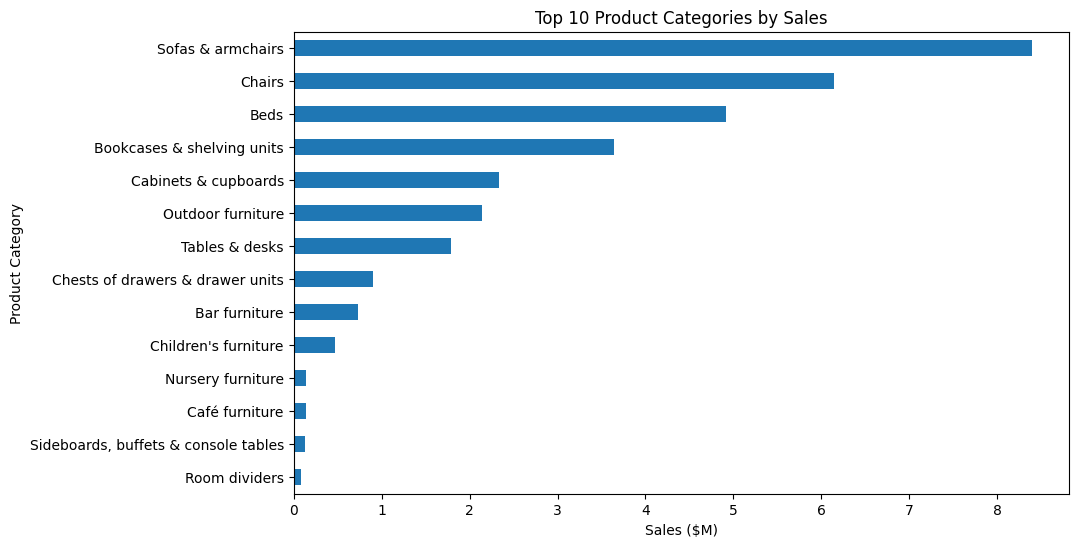

In [ ]:
category_sales_m = category_sales['total_sales'] / 1000000

category_sales_m = category_sales_m.sort_values()

plt.figure(figsize=(10, 6))
category_sales_m.plot(kind='barh')

plt.title('Top 10 Product Categories by Sales')
plt.xlabel('Sales ($M)')
plt.ylabel('Product Category')

plt.show()

Sofas & armchairs generated the highest total sales among all product categories, reaching 8.39M, followed by Chairs with 6.15M and Beds with 4.92M.

Bookcases & shelving units had the highest number of orders (7,630), but their average order value was only 477.17. In contrast, Sofas & armchairs generated fewer orders (4,301) but had the highest average order value (1,950.30). This shows that total sales are driven by a combination of order volume and average order value.

### 4.3 Top 10 categories in the US

In [ ]:
us_category_sales = (
    df[
        (df["country"] == "United States") &
        (df["price"].notna())
    ]
    .groupby("product_category")
    .agg(
        total_sales=("price", "sum"),
        order_count=("price", "count"),
        avg_order_value=("price", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

top_10_us_categories = us_category_sales.head(10)

print("Top 10 categories in US:")

top_10_us_categories

Top 10 categories in US:


,total_sales,order_count,avg_order_value
product_category,,,
Sofas & armchairs,3707144.5,1903,1948.052811
Chairs,2619773.8,2576,1016.992935
Beds,2213058.0,1298,1704.975347
Bookcases & shelving units,1567606.9,3374,464.613782
Cabinets & cupboards,994545.5,995,999.543216
Outdoor furniture,929245.2,984,944.354878
Tables & desks,777865.0,1248,623.289263
Chests of drawers & drawer units,382388.0,616,620.759740
Bar furniture,330805.0,487,679.271047


The product category structure in the United States closely matches the overall market. The same ten categories appear in the top 10, and their ranking is identical to the overall ranking.

Sofas & armchairs, Chairs, and Beds remain the three largest categories in terms of total sales. This suggests that the United States follows the overall sales pattern rather than having a substantially different product category structure.

### 4.4 Sales by device type + models

In [ ]:
device_sales = (
    df.dropna(subset=["price"])
      .groupby("device")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

device_sales["sales_share"] = (
    device_sales["total_sales"] / device_sales["total_sales"].sum() * 100
)

print("Sales by device type:")

device_sales

Sales by device type:


,total_sales,order_count,sales_share
device,,,
desktop,18864039.0,19702,59.002245
mobile,12384225.8,13113,38.734924
tablet,723466.3,723,2.262831


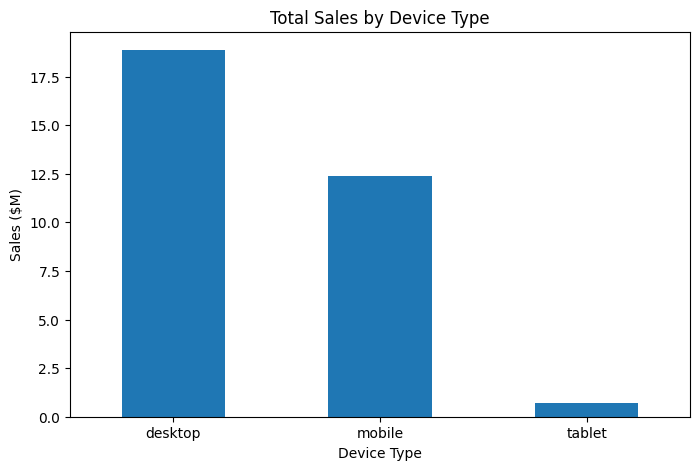

In [ ]:
device_sales_m = device_sales["total_sales"] / 1000000

plt.figure(figsize=(8, 5))
device_sales_m.plot(kind='bar')

plt.title('Total Sales by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Sales ($M)')
plt.xticks(rotation=0)

plt.show()

Desktop devices generated the majority of total sales, accounting for 59.00% of all sales. Mobile devices contributed 38.73%, while tablets accounted for only 2.26%.

Together, desktop and mobile devices generated 97.74% of total sales, indicating that tablets play a very minor role in the company's sales.

In [ ]:
df["device_model"].value_counts()

,count
device_model,
Chrome,97254
iPhone,71326
Safari,70891
<Other>,70839
ChromeBook,19084
Edge,7907
iPad,5090
Firefox,4874
Pixel 4 XL,1246


In [ ]:
identifiable_device_models = [
    "iPhone",
    "ChromeBook",
    "iPad",
    "Pixel 4 XL",
    "Pixel 3"
]

device_model_sales = (
    df[df["device_model"].isin(identifiable_device_models)]
    .dropna(subset=["price"])
    .groupby("device_model")
    .agg(
        total_sales=("price", "sum"),
        order_count=("price", "count")
    )
    .sort_values("total_sales", ascending=False)
)

device_model_sales["sales_share"] = (
    device_model_sales["total_sales"]
    / device_model_sales["total_sales"].sum()
    * 100
)

print("Sales by device models:")

device_model_sales

Sales by device models:


,total_sales,order_count,sales_share
device_model,,,
iPhone,6420776.3,6819,71.921123
ChromeBook,1830458.7,1877,20.503540
iPad,448854.2,456,5.027756
Pixel 4 XL,118287.7,117,1.324978
Pixel 3,109148.2,105,1.222603


Among the identified device models, iPhone generated the largest share of sales (71.92%), followed by ChromeBook (20.50%). iPad accounted for 5.03%, while Pixel 4 XL and Pixel 3 contributed only 1.32% and 1.22%, respectively.

This indicates that iPhone users represent the dominant share of sales among customers with an identifiable device model. However, these percentages are calculated only for the five identified device models and should not be interpreted as shares of total sales.

### 4.5 Sales by traffic source/channel

In [ ]:
traffic_source_sales = (
    df.dropna(subset=["price"])
      .groupby("traffic_source")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

traffic_source_sales["sales_share"] = (
    traffic_source_sales["total_sales"]
    / traffic_source_sales["total_sales"].sum()
    * 100
)

print("Sales by traffic source:")

traffic_source_sales

Sales by traffic source:


,total_sales,order_count,sales_share
traffic_source,,,
(organic),10935239.9,11430,34.202840
(direct),7494923.4,7800,23.442345
<Other>,5897375.6,6252,18.445594
(referral),5641855.2,6001,17.646386
(data deleted),2002337.0,2055,6.262836


Organic traffic was the largest source of sales, accounting for 34.20% of total sales. Direct traffic ranked second with 23.44%.

Together, organic and direct traffic generated 57.65% of total sales, meaning that more than half of sales came from these two sources.

The remaining sales were distributed among referral traffic, other sources, and records with deleted source information. Therefore, the contribution of these categories should be interpreted with caution.

In [ ]:
traffic_channel_sales = (
    df.dropna(subset=["price"])
      .groupby("traffic_channel")
      .agg(
          total_sales=("price", "sum"),
          order_count=("price", "count")
      )
      .sort_values("total_sales", ascending=False)
)

traffic_channel_sales["sales_share"] = (
    traffic_channel_sales["total_sales"]
    / traffic_channel_sales["total_sales"].sum()
    * 100
)

print("Sales by traffic channel:")

traffic_channel_sales

Sales by traffic channel:


,total_sales,order_count,sales_share
traffic_channel,,,
Organic Search,11433151.6,11921,35.760189
Paid Search,8511049.4,9042,26.620546
Direct,7494923.4,7800,23.442345
Social Search,2532105.7,2716,7.919827
Undefined,2000501.0,2059,6.257093


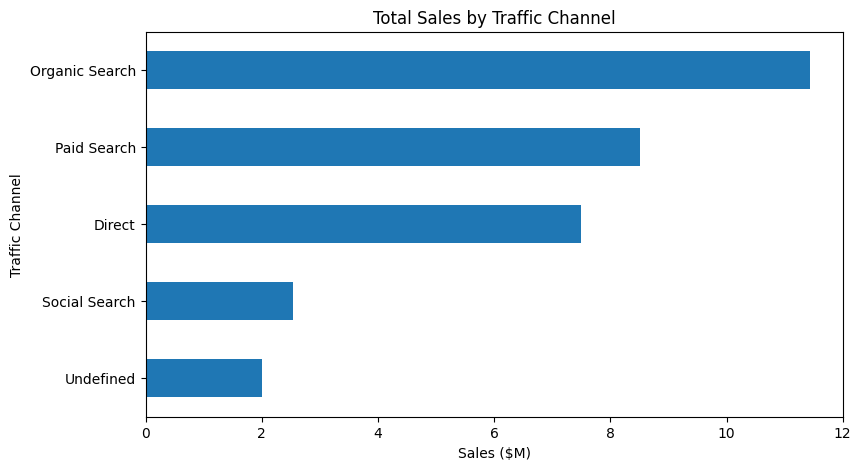

In [ ]:
channel_sales_m = traffic_channel_sales["total_sales"] / 1000000

channel_sales_m = channel_sales_m.sort_values()

plt.figure(figsize=(9, 5))
channel_sales_m.plot(kind='barh')

plt.title('Total Sales by Traffic Channel')
plt.xlabel('Sales ($M)')
plt.ylabel('Traffic Channel')

plt.show()

Organic Search was the largest traffic channel, generating 35.76% of total sales. Paid Search ranked second with 26.62%, followed by Direct traffic with 23.44%.

Together, Organic Search and Paid Search accounted for 62.38% of total sales, indicating that search-based traffic is the main contributor to the company's sales.

Social Search generated a smaller share of sales (7.92%), while 6.26% of sales were associated with undefined traffic channels and therefore cannot be reliably attributed to a specific channel.

### 4.6 Email verification rate

Calculate the percentage of registered users who have verified their email address.

In [ ]:
registered_users = df[df['user_id'].notna()][
    ['user_id', 'email_verified', 'newsletter_unsubscribed']
].drop_duplicates()

verification_rate = (
    registered_users['email_verified'].mean() * 100
)

print(f"Email verification rate: {verification_rate:.2f}%")

Email verification rate: 71.70%


The email verification rate among registered users was 71.70%, meaning that nearly three-quarters of registered users had confirmed their email address.

### 4.7 Newsletter unsubscribe rate

In [ ]:
unsubscribe_rate = (
    registered_users['newsletter_unsubscribed'].mean() * 100
)

print(f"Newsletter unsubscribe rate: {unsubscribe_rate:.2f}%")

Newsletter unsubscribe rate: 16.94%


The newsletter unsubscribe rate among registered users was 16.94%, meaning that approximately one in six registered users had unsubscribed from the newsletter.

### 4.8 Subscribed vs. unsubscribed users

In [ ]:
registered_sales = df[df['user_id'].notna() & df['price'].notna()].copy()

subscribed_users = registered_sales[
    registered_sales['newsletter_unsubscribed'] == 0
]

unsubscribed_users = registered_sales[
    registered_sales['newsletter_unsubscribed'] == 1
]

sales_comparison = pd.DataFrame({
    'total_sales': [
        subscribed_users['price'].sum(),
        unsubscribed_users['price'].sum()
    ],
    'order_count': [
        subscribed_users['price'].count(),
        unsubscribed_users['price'].count()
    ],
    'avg_order_value': [
        subscribed_users['price'].mean(),
        unsubscribed_users['price'].mean()
    ]
}, index=['Subscribed', 'Unsubscribed'])

sales_comparison

,total_sales,order_count,avg_order_value
Subscribed,2150796.9,2334,921.506812
Unsubscribed,431721.6,447,965.820134


The subscribed group generated higher total sales (2.15M) and had more orders (2,334) than the unsubscribed group (431.72K and 447 orders, respectively).

However, unsubscribed users had a higher average order value (965.82 vs. 921.51), which is approximately 4.8% higher. This difference may indicate different purchasing behavior between the groups, but statistical testing is required to determine whether the difference is statistically significant.

## 5. Analysis of sales dynamics

### 5.1 Total sales by date

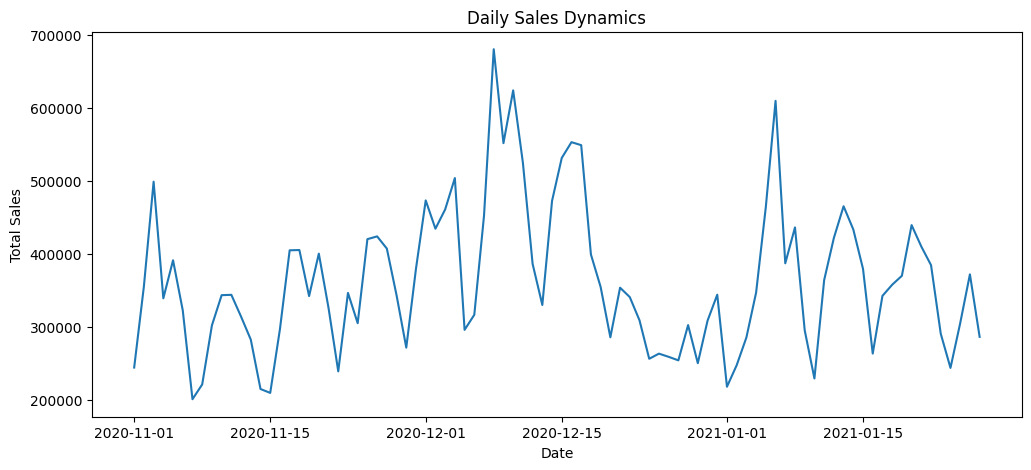

In [ ]:
daily_sales = (
    df[df['price'].notna()]
    .groupby('session_date')['price']
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 5))

daily_sales.plot()

plt.title('Daily Sales Dynamics')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.show()

In [ ]:
daily_sales_df = daily_sales.reset_index()
daily_sales_df.columns = ['date', 'sales']

daily_sales_df['date'] = pd.to_datetime(daily_sales_df['date'])

daily_sales_df['day_of_week'] = daily_sales_df['date'].dt.day_name()

weekday_sales = (
    daily_sales_df
    .groupby('day_of_week')['sales']
    .mean()
    .reindex([
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ])
)

weekday_sales

,sales
day_of_week,
Monday,356637.723077
Tuesday,419808.915385
Wednesday,420503.300000
Thursday,411411.300000
Friday,376922.266667
Saturday,289832.575000
Sunday,267183.707692


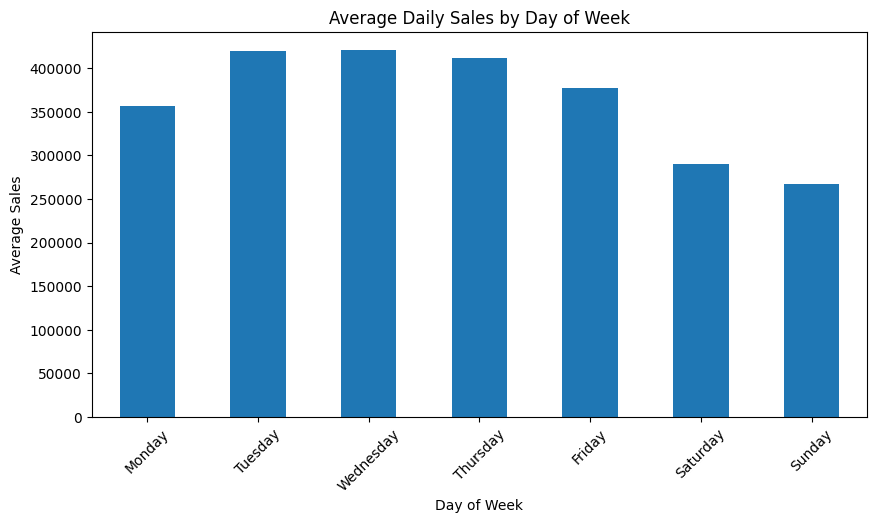

In [ ]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind='bar')

plt.title('Average Daily Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)

plt.show()

Average daily sales are highest on Wednesday (420.5K), followed by Tuesday (419.8K) and Thursday (411.4K).

Sales are noticeably lower on weekends, with Sunday having the lowest average daily sales (267.2K).

Overall, the data suggests that sales activity is stronger during the middle of the working week and weaker on weekends.

In [ ]:
continent_daily_sales = (
    df.dropna(subset=['price'])
      .groupby(['session_date', 'continent'])['price']
      .sum()
      .reset_index()
)

continent_daily_sales['session_date'] = pd.to_datetime(
    continent_daily_sales['session_date']
)

continent_daily_sales.head()

,session_date,continent,price
0,2020-11-01,Africa,1184.0
1,2020-11-01,Americas,132002.5
2,2020-11-01,Asia,63823.0
3,2020-11-01,Europe,46908.0
4,2020-11-01,Oceania,375.0


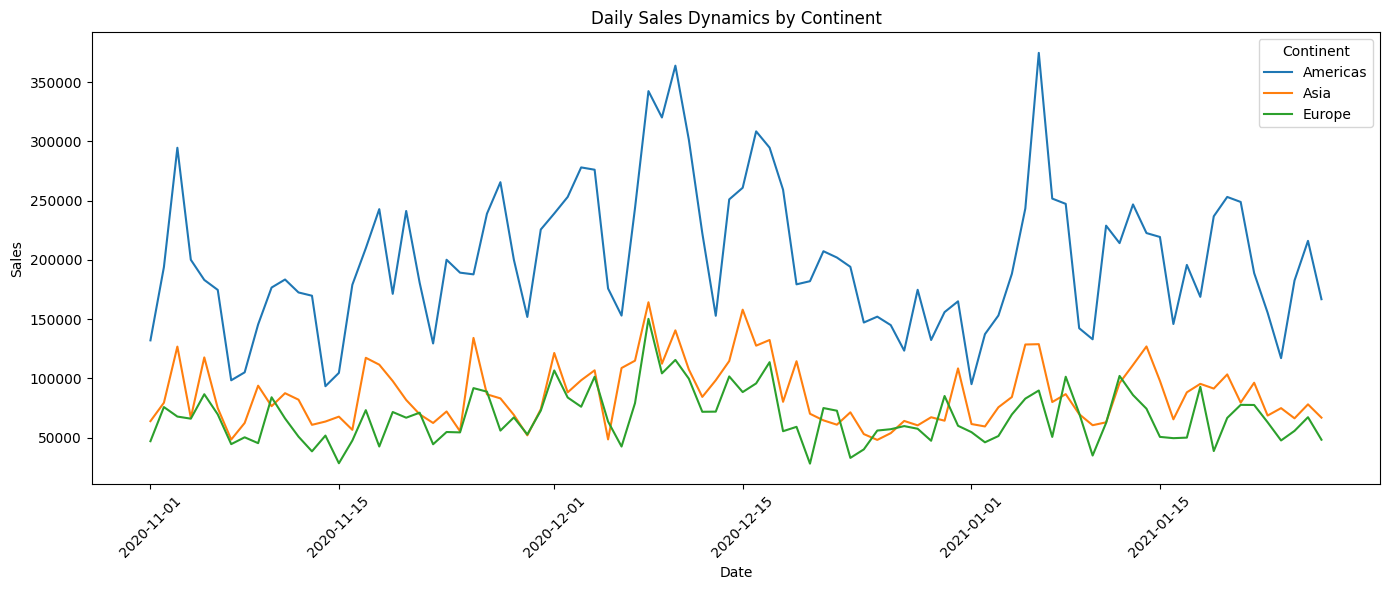

In [ ]:
plt.figure(figsize=(14, 6))

for continent in ['Americas', 'Asia', 'Europe']:
    data = continent_daily_sales[
        continent_daily_sales['continent'] == continent
    ]

    plt.plot(
        data['session_date'],
        data['price'],
        label=continent
    )

plt.title('Daily Sales Dynamics by Continent')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend(title='Continent')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Americas consistently generated the highest sales throughout the analyzed period, significantly exceeding Asia and Europe. Sales in Asia and Europe followed a similar pattern with noticeable daily fluctuations, but remained substantially lower than the Americas.

Overall, the sales dynamics across the three continents show similar short-term fluctuations, while the main difference is the consistently higher sales volume in the Americas.

In [ ]:
channel_sales = (
    df.groupby(['session_date', 'traffic_channel'])['price']
    .sum()
    .reset_index()
)

channel_sales.columns = ['date', 'traffic_channel', 'sales']

channel_sales['date'] = pd.to_datetime(channel_sales['date'])

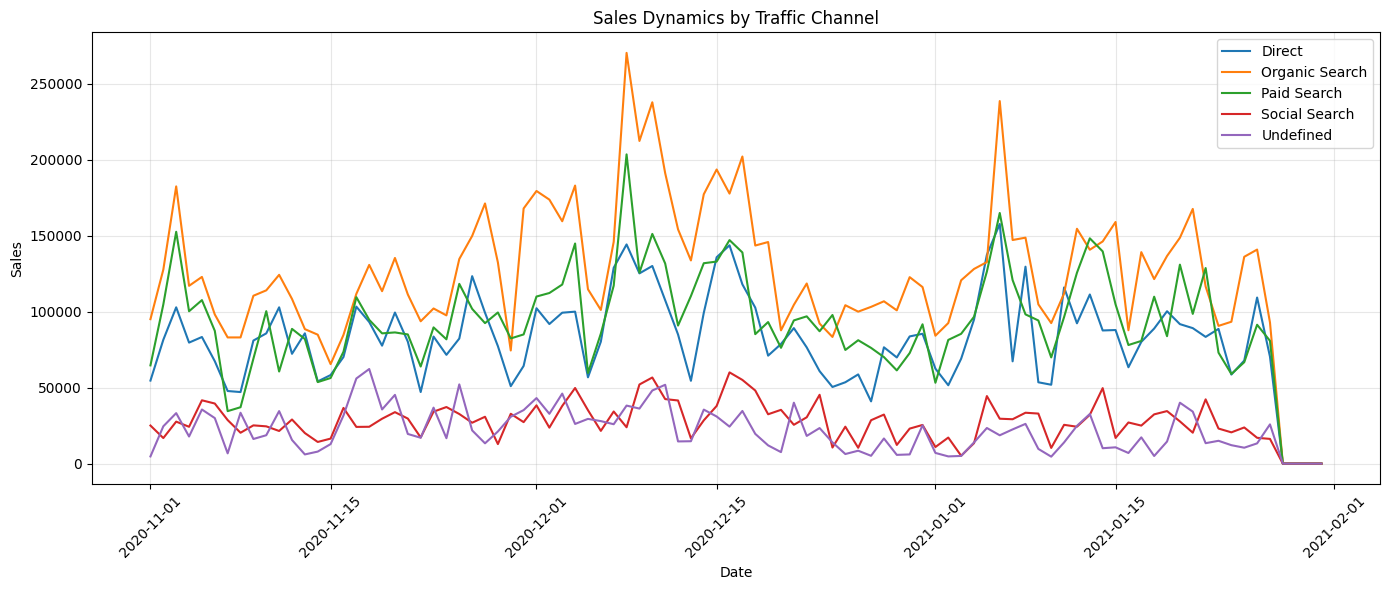

In [ ]:
plt.figure(figsize=(14, 6))

for channel in channel_sales['traffic_channel'].unique():
    data = channel_sales[channel_sales['traffic_channel'] == channel]
    plt.plot(data['date'], data['sales'], label=channel)

plt.title('Sales Dynamics by Traffic Channel')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Organic Search generated the highest sales throughout most of the analyzed period, followed by Paid Search and Direct traffic. Social Search contributed considerably less sales, while Undefined traffic remained the smallest channel.

Overall, the traffic channels show similar short-term fluctuations, but Organic Search consistently maintains the highest sales level.

In [ ]:
device_daily_sales = (
    df.groupby(['session_date', 'device'])['price']
    .sum()
    .reset_index()
)

device_daily_sales.columns = ['date', 'device', 'sales']

device_daily_sales['date'] = pd.to_datetime(device_daily_sales['date'])

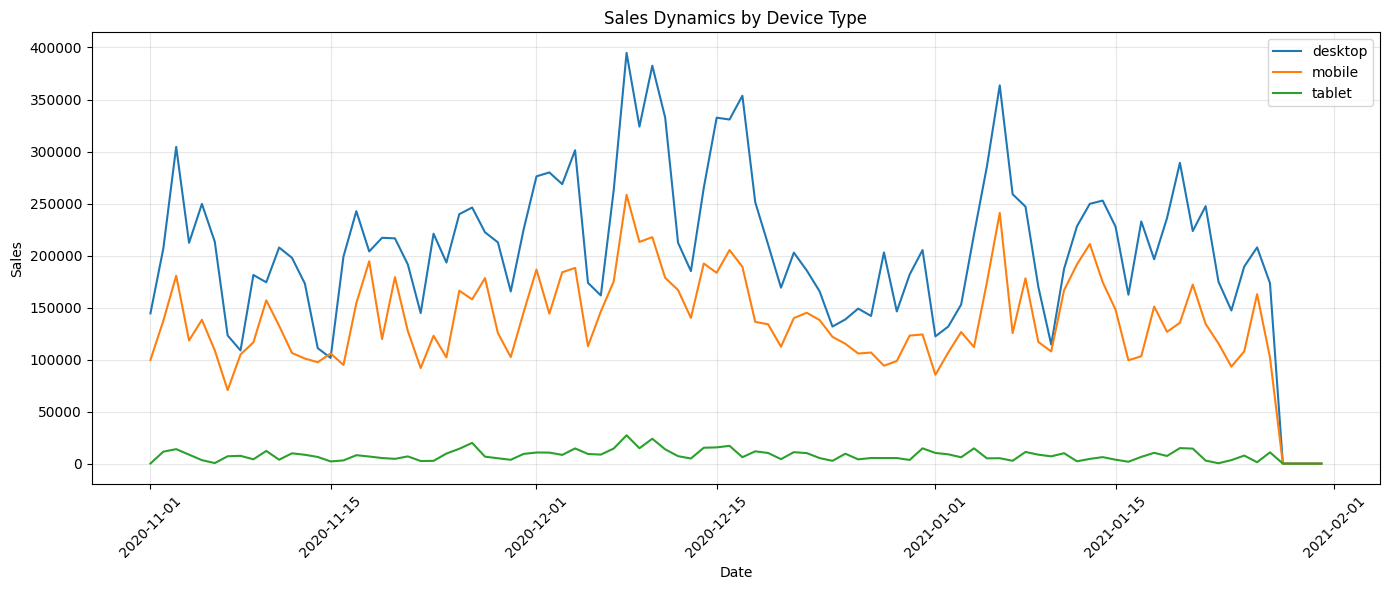

In [ ]:
plt.figure(figsize=(14, 6))

for device in device_daily_sales['device'].unique():
    data = device_daily_sales[device_daily_sales['device'] == device]
    plt.plot(data['date'], data['sales'], label=device)

plt.title('Sales Dynamics by Device Type')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Desktop generated the highest sales throughout the analyzed period, consistently remaining well above mobile and tablet devices. Mobile sales were the second largest, while tablet sales were significantly lower.

The three device types generally followed similar short-term fluctuations, but the overall sales structure remained stable, with desktop as the dominant device type and tablet contributing only a small share of total sales.

## 6. Pivot tables

### 6.1 Sessions by traffic channel and device

In [ ]:
sessions_pivot = (
    df.dropna(subset=['traffic_channel', 'device'])
      .pivot_table(
          index='traffic_channel',
          columns='device',
          values='session_id',
          aggfunc='count',
          fill_value=0
      )
)

sessions_pivot

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


### 6.2 Sales by top 10 categories in top 5 countries

In [ ]:
top_countries = (
    df.groupby('country')['price']
    .sum()
    .nlargest(5)
    .index
)

top_categories = (
    df.groupby('product_category')['price']
    .sum()
    .nlargest(10)
    .index
)

pivot_sales = pd.pivot_table(
    df[
        df['country'].isin(top_countries) &
        df['product_category'].isin(top_categories)
    ],
    values='price',
    index='product_category',
    columns='country',
    aggfunc='sum',
    fill_value=0
)

pivot_sales

country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


### 6.3 Average order value by top 5 countries and device type

In [ ]:
pivot_aov = pd.pivot_table(
    df[df['country'].isin(top_countries)],
    values='price',
    index='country',
    columns='device',
    aggfunc='mean',
    fill_value=0
)

pivot_aov

device,desktop,mobile,tablet
country,,,
Canada,951.830530,945.819583,1117.327273
France,1041.356250,1049.532959,1265.909091
India,903.054992,949.138174,1227.490909
United Kingdom,901.255611,923.517413,995.380952
United States,963.314999,930.919043,948.188323


### 6.4 Total sales by continent and top 10 categories

In [ ]:
pivot_continent_category = pd.pivot_table(
    df[
        (df['continent'] != '(not set)') &
        df['product_category'].isin(top_categories)
    ],
    values='price',
    index='continent',
    columns='product_category',
    aggfunc='sum',
    fill_value=0
)

pivot_continent_category

product_category,Bar furniture,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Chests of drawers & drawer units,Children's furniture,Outdoor furniture,Sofas & armchairs,Tables & desks
continent,,,,,,,,,,
Africa,10724.0,57567.5,32996.7,21106.0,44877.0,10941.0,3962.0,16343.8,108120.0,21658.0
Americas,406198.0,2773094.0,1968919.3,1275562.5,3309203.0,484290.0,253435.0,1213115.2,4737307.0,968129.0
Asia,176684.0,1077325.5,945368.9,545369.5,1524600.8,210383.5,112389.0,488607.6,1950022.0,464192.5
Europe,131110.0,925047.5,650889.5,468652.5,1178581.0,186793.0,93479.0,399553.2,1491224.5,307045.0
Oceania,10787.0,77125.5,40046.7,20682.0,73356.0,12145.0,4314.0,21471.0,78236.0,21287.0


In [ ]:
daily_sessions = (
    df.groupby('session_date')['session_id']
    .nunique()
    .reset_index(name='sessions')
)

daily_sales = (
    df.groupby('session_date')['price']
    .sum()
    .reset_index(name='sales')
)

daily_metrics = daily_sessions.merge(
    daily_sales,
    on='session_date'
)

daily_metrics.head()

,session_date,sessions,sales
0,2020-11-01,2576,244292.5
1,2020-11-02,3599,355506.8
2,2020-11-03,5173,498979.6
3,2020-11-04,4184,339187.1
4,2020-11-05,3743,391276.6


## 7. Statistical Analysis of Relationships

### 7.1. Sessions vs Sales

Pearson correlation: 0.791
P-value: 0.00000


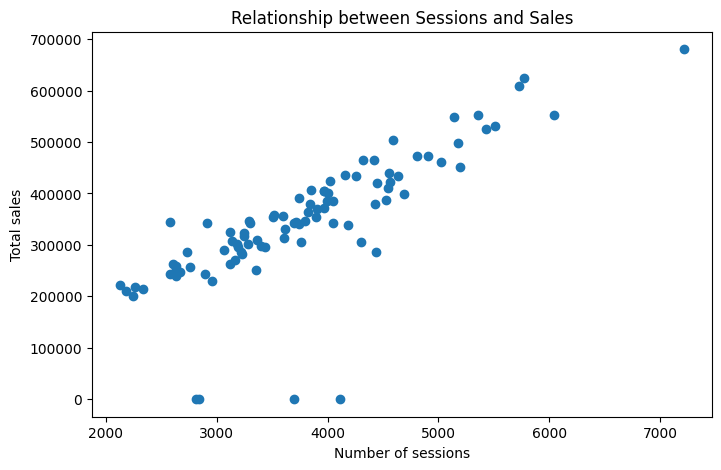

In [ ]:
corr, p_value = pearsonr(daily_metrics['sessions'], daily_metrics['sales'])

print(f"Pearson correlation: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

plt.figure(figsize=(8, 5))
plt.scatter(daily_metrics['sessions'], daily_metrics['sales'])

plt.xlabel('Number of sessions')
plt.ylabel('Total sales')
plt.title('Relationship between Sessions and Sales')

plt.show()

There is a strong positive correlation between the number of sessions and total sales (Pearson's r = 0.791). This relationship is statistically significant (p < 0.05), indicating that days with more sessions tend to generate higher sales.

However, correlation does not imply causation.

### 7.2. Sales correlation between top 3 continents

In [ ]:
continent_daily_sales_cor = (
    df[df['continent'].isin(['Americas', 'Asia', 'Europe'])]
    .groupby(['session_date', 'continent'])['price']
    .sum()
    .unstack(fill_value=0)
)

continent_correlation_matrix = continent_daily_sales_cor.corr()

print("Correlation matrix:")
display(continent_correlation_matrix)

continents = ['Americas', 'Asia', 'Europe']

for i in range(len(continents)):
    for j in range(i + 1, len(continents)):
        continent_1 = continents[i]
        continent_2 = continents[j]

        corr, p_value = pearsonr(
            continent_daily_sales_cor[continent_1],
            continent_daily_sales_cor[continent_2]
        )

        print(
            f"{continent_1} vs {continent_2}: "
            f"r = {corr:.3f}, p-value = {p_value:5f}"
        )

Correlation matrix:


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.792025,0.770586
Asia,0.792025,1.000000,0.768427
Europe,0.770586,0.768427,1.000000


Americas vs Asia: r = 0.792, p-value = 0.000000
Americas vs Europe: r = 0.771, p-value = 0.000000
Asia vs Europe: r = 0.768, p-value = 0.000000


Sales across the top three continents show strong positive correlations.

- Americas and Asia: r = 0.792
- Americas and Europe: r = 0.771
- Asia and Europe: r = 0.768

All correlations are statistically significant (p < 0.05). This indicates that sales in these regions tend to increase and decrease together over time.

### 7.3. Sales correlation between traffic channels

In [ ]:
channel_daily_sales = (
    df.groupby(['session_date', 'traffic_channel'])['price']
    .sum()
    .unstack(fill_value=0)
)

channel_correlation_matrix = channel_daily_sales.corr()

print("Correlation matrix:")
display(channel_correlation_matrix)

channels = channel_daily_sales.columns.tolist()

for i in range(len(channels)):
    for j in range(i + 1, len(channels)):
        channel_1 = channels[i]
        channel_2 = channels[j]

        corr, p_value = pearsonr(
            channel_daily_sales[channel_1],
            channel_daily_sales[channel_2]
        )

        print(
            f"{channel_1} vs {channel_2}: "
            f"r = {corr:.3f}, p-value = {p_value:.5f}"
        )

Correlation matrix:


traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
traffic_channel,,,,,
Direct,1.000000,0.837833,0.814072,0.604060,0.517505
Organic Search,0.837833,1.000000,0.870086,0.583117,0.526068
Paid Search,0.814072,0.870086,1.000000,0.596428,0.521961
Social Search,0.604060,0.583117,0.596428,1.000000,0.455126
Undefined,0.517505,0.526068,0.521961,0.455126,1.000000


Direct vs Organic Search: r = 0.838, p-value = 0.00000
Direct vs Paid Search: r = 0.814, p-value = 0.00000
Direct vs Social Search: r = 0.604, p-value = 0.00000
Direct vs Undefined: r = 0.518, p-value = 0.00000
Organic Search vs Paid Search: r = 0.870, p-value = 0.00000
Organic Search vs Social Search: r = 0.583, p-value = 0.00000
Organic Search vs Undefined: r = 0.526, p-value = 0.00000
Paid Search vs Social Search: r = 0.596, p-value = 0.00000
Paid Search vs Undefined: r = 0.522, p-value = 0.00000
Social Search vs Undefined: r = 0.455, p-value = 0.00001


Sales across all traffic channels show statistically significant positive correlations (p < 0.05).

The strongest correlation is observed between Organic Search and Paid Search (r = 0.870), followed by Direct and Organic Search (r = 0.838) and Direct and Paid Search (r = 0.814).

The weakest relationship is between Social Search and Undefined (r = 0.455), although it is still statistically significant.

Overall, sales from different traffic channels tend to move in the same direction over time. However, these correlations do not imply that one traffic channel causes changes in another.

### 7.4. Top 5 Categories correlation

In [ ]:
category_daily_sales = (
    df[df['product_category'].isin(top_categories[:5])]
    .groupby(['session_date', 'product_category'])['price']
    .sum()
    .unstack(fill_value=0)
)

category_correlation_matrix = category_daily_sales.corr()

print("Correlation matrix:")
display(category_correlation_matrix)

categories = category_daily_sales.columns.tolist()

for i in range(len(categories)):
    for j in range(i + 1, len(categories)):
        category_1 = categories[i]
        category_2 = categories[j]

        corr, p_value = pearsonr(
            category_daily_sales[category_1],
            category_daily_sales[category_2]
        )

        print(
            f"{category_1} vs {category_2}: "
            f"r = {corr:.3f}, p-value = {p_value:.5f}"
        )

Correlation matrix:


product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


Beds vs Bookcases & shelving units: r = 0.593, p-value = 0.00000
Beds vs Cabinets & cupboards: r = 0.515, p-value = 0.00000
Beds vs Chairs: r = 0.554, p-value = 0.00000
Beds vs Sofas & armchairs: r = 0.535, p-value = 0.00000
Bookcases & shelving units vs Cabinets & cupboards: r = 0.539, p-value = 0.00000
Bookcases & shelving units vs Chairs: r = 0.637, p-value = 0.00000
Bookcases & shelving units vs Sofas & armchairs: r = 0.666, p-value = 0.00000
Cabinets & cupboards vs Chairs: r = 0.573, p-value = 0.00000
Cabinets & cupboards vs Sofas & armchairs: r = 0.658, p-value = 0.00000
Chairs vs Sofas & armchairs: r = 0.578, p-value = 0.00000


All top-5 product categories show statistically significant positive correlations in daily sales (`p < 0.001` for all pairs).

The strongest correlation is observed between **Bookcases & shelving units** and **Sofas & armchairs** (`r = 0.666`). The weakest correlation is between **Beds** and **Cabinets & cupboards** (`r = 0.515`).

Overall, sales across the major product categories tend to increase and decrease together, which may indicate common demand patterns or the influence of shared factors such as seasonality, promotions, or overall customer activity.


### 7.5. Correlation between Sessions and Sales by Continent

In [ ]:
continent_daily = (
    df.groupby(['session_date', 'continent'])
      .agg(
          sessions=('session_id', 'nunique'),
          sales=('price', 'sum')
      )
      .reset_index()
)

top_continents = ['Americas', 'Asia', 'Europe']

for continent in top_continents:
    data = continent_daily[
        continent_daily['continent'] == continent
    ]

    r, p = pearsonr(data['sessions'], data['sales'])

    print(f"{continent}:")
    print(f"Pearson correlation: {r:.3f}")
    print(f"P-value: {p:.5f}")
    print()

Americas:
Pearson correlation: 0.793
P-value: 0.00000

Asia:
Pearson correlation: 0.655
P-value: 0.00000

Europe:
Pearson correlation: 0.687
P-value: 0.00000



The analysis shows a positive correlation between the number of sessions and sales across all three major continents.

All correlations are statistically significant. The strongest relationship is observed in the **Americas**, suggesting that changes in the number of sessions are more strongly associated with changes in sales in this region.

Overall, higher customer activity is associated with higher sales across all three continents, although the strength of this relationship differs by region.


### 7.6. Correlation between Sales by Device Type

In [ ]:
device_daily_sales = (
    df.groupby(['session_date', 'device'])['price']
      .sum()
      .unstack(fill_value=0)
)

print("Correlation matrix:")
display(device_daily_sales.corr())

devices = device_daily_sales.columns.tolist()

for i in range(len(devices)):
    for j in range(i + 1, len(devices)):
        device_1 = devices[i]
        device_2 = devices[j]

        r, p_value = pearsonr(
            device_daily_sales[device_1],
            device_daily_sales[device_2]
        )

        print(
            f"{device_1} vs {device_2}: "
            f"r = {r:.3f}, p-value = {p_value:.5f}"
        )

Correlation matrix:


device,desktop,mobile,tablet
device,,,
desktop,1.000000,0.873201,0.601354
mobile,0.873201,1.000000,0.567394
tablet,0.601354,0.567394,1.000000


desktop vs mobile: r = 0.873, p-value = 0.00000
desktop vs tablet: r = 0.601, p-value = 0.00000
mobile vs tablet: r = 0.567, p-value = 0.00000


To analyze whether sales from different device types change together, Pearson correlation coefficients were calculated for desktop, mobile, and tablet sales.

The results show statistically significant positive correlations between all device types.

The strongest relationship is observed between **desktop and mobile sales (r = 0.873)**. This indicates that these two device types tend to experience similar changes in daily sales.

All correlations are statistically significant (p < 0.05), suggesting that the observed relationships are unlikely to be caused by random variation.

## 8. Statistical Analysis of Differences Between Groups

### 8.1. Purchase Value by User Type

In [ ]:
purchase_data = df[df['price'] > 0].copy()

purchase_data['user_type'] = purchase_data['user_id'].notna().map({
    True: 'Registered',
    False: 'Unregistered'
})

registered_prices = purchase_data.loc[
    purchase_data['user_type'] == 'Registered',
    'price'
]

unregistered_prices = purchase_data.loc[
    purchase_data['user_type'] == 'Unregistered',
    'price'
]

u_stat, p_value = mannwhitneyu(
    registered_prices,
    unregistered_prices,
    alternative='two-sided'
)

print(f"Mann-Whitney U statistic: {u_stat:.1f}")
print(f"P-value: {p_value:.5f}")

Mann-Whitney U statistic: 41771375.0
P-value: 0.04159


To compare the purchase values of registered and unregistered users, only records with `price > 0` were considered. Since the purchase values are strongly right-skewed, the **Mann-Whitney U test** was used.

Since p < 0.05, the null hypothesis is rejected. Therefore, there is a **statistically significant difference in purchase values between registered and unregistered users**.

### 8.2. Sessions Comparison between Traffic Channels

In [ ]:
daily_channel_sessions = (
    df.groupby(['session_date', 'traffic_channel'])['session_id']
      .nunique()
      .unstack(fill_value=0)
)

display(daily_channel_sessions.head())

traffic_channel,Direct,Organic Search,Paid Search,Social Search,Undefined
session_date,,,,,
2020-11-01,608,920,706,214,128
2020-11-02,810,1242,970,315,262
2020-11-03,1216,1871,1367,392,327
2020-11-04,935,1425,1145,368,311
2020-11-05,845,1293,917,346,342


In [ ]:
for channel in daily_channel_sessions.columns:
    stat, p_value = shapiro(daily_channel_sessions[channel])
    print(f"{channel}: W = {stat:.3f}, p-value = {p_value:.5f}")

Direct: W = 0.970, p-value = 0.03428
Organic Search: W = 0.964, p-value = 0.01227
Paid Search: W = 0.963, p-value = 0.01083
Social Search: W = 0.979, p-value = 0.14127
Undefined: W = 0.973, p-value = 0.05456


In [ ]:
groups = [
    daily_channel_sessions[channel].values
    for channel in daily_channel_sessions.columns
]

friedman_stat, p_value = friedmanchisquare(*groups)

print(f"Friedman statistic: {friedman_stat:.3f}")
print(f"P-value: {p_value:.5f}")

Friedman statistic: 368.000
P-value: 0.00000


Daily session counts were compared across five traffic channels: Direct, Organic Search, Paid Search, Social Search, and Undefined.

The **Shapiro-Wilk test** was used as an exploratory check of the distributions. Direct, Organic Search, and Paid Search showed statistically significant deviations from normality (p < 0.05), while Social Search and Undefined did not.

Since daily session counts for all traffic channels were measured on the same dates, the observations represent **related samples**. Therefore, the **Friedman test** was used to compare daily session counts across the five traffic channels.

Since p < 0.05, the null hypothesis is rejected. Therefore, there are **statistically significant differences in daily session counts between the traffic channels**.

### 8.3. Comparison of Organic Traffic Session Proportions between Europe and Americas

In [ ]:
organic_sessions = (
    df[df['traffic_channel'] == 'Organic Search']
    .groupby('continent')['session_id']
    .nunique()
)

total_sessions = (
    df.groupby('continent')['session_id']
    .nunique()
)

europe_organic = organic_sessions['Europe']
europe_total = total_sessions['Europe']

americas_organic = organic_sessions['Americas']
americas_total = total_sessions['Americas']

print(f"Europe: {europe_organic} organic sessions out of {europe_total} total sessions")
print(f"Americas: {americas_organic} organic sessions out of {americas_total} total sessions")

print(f"Europe organic share: {europe_organic / europe_total:.2%}")
print(f"Americas organic share: {americas_organic / americas_total:.2%}")

Europe: 23195 organic sessions out of 65135 total sessions
Americas: 68671 organic sessions out of 193179 total sessions
Europe organic share: 35.61%
Americas organic share: 35.55%


In [ ]:
counts = [europe_organic, americas_organic]
nobs = [europe_total, americas_total]

z_stat, p_value = proportions_ztest(counts, nobs)

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.5f}")

Z-statistic: 0.290
P-value: 0.77219


The proportion of sessions generated through organic traffic was compared between Europe and Americas using a **two-proportion z-test**.

The input data were:

* **Europe:** 23,195 organic sessions out of 65,135 total sessions — **35.61%**
* **Americas:** 68,671 organic sessions out of 193,179 total sessions — **35.55%**

The test results were:

* **Z-statistic:** 0.290
* **p-value:** 0.77219

Since p > 0.05, the null hypothesis is not rejected. Therefore, there is **no statistically significant difference in the proportion of organic traffic sessions between Europe and Americas**.

### 8.4. Sales Comparison between Desktop and Mobile Users

In [ ]:
daily_device_sales = (
    df.groupby(['session_date', 'device'])['price']
      .sum()
      .unstack(fill_value=0)
)

display(daily_device_sales[['desktop', 'mobile']].head())

device,desktop,mobile
session_date,,
2020-11-01,144445.0,99698.5
2020-11-02,206727.3,137269.5
2020-11-03,304473.8,180602.8
2020-11-04,212227.7,118324.4
2020-11-05,249682.0,138256.0


In [ ]:
desktop_sales = daily_device_sales['desktop']
mobile_sales = daily_device_sales['mobile']

device_sales_diff = desktop_sales - mobile_sales

diff_stat, diff_p = shapiro(device_sales_diff)

print(f"Desktop vs Mobile differences: W = {diff_stat:.3f}, p-value = {diff_p:.5f}")

Desktop vs Mobile differences: W = 0.980, p-value = 0.18272


In [ ]:
t_stat, p_value = ttest_rel(
    desktop_sales,
    mobile_sales
)

print(f"Paired t-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

Paired t-statistic: 16.107
P-value: 0.00000


Daily sales from desktop and mobile devices were compared using a **paired statistical approach**, since daily sales for both device types were measured on the same dates.

First, the differences between desktop and mobile daily sales were calculated and tested for normality using the **Shapiro-Wilk test**:

* **Differences:** p = 0.18272 → there is no statistically significant evidence that the differences deviate from a normal distribution.

Since the paired differences did not significantly deviate from normality, the **paired t-test** was used to compare the mean daily sales between desktop and mobile devices.

Since p < 0.05, the null hypothesis of equal mean daily sales was rejected. Therefore, there is a **statistically significant difference in average daily sales between desktop and mobile devices**.

### 8.5. Association between Device Type and Traffic Channel

In [ ]:
contingency_table = pd.crosstab(
    df['traffic_channel'],
    df['device']
)

display(contingency_table)

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"P-value: {p_value:.5f}")

Chi-square statistic: 4.739
P-value: 0.78506


A **Chi-square test of independence** was used to determine whether there is a statistically significant association between device type and traffic channel.

The contingency table included three device types (desktop, mobile, and tablet) and five traffic channels.

Since p > 0.05, the null hypothesis of independence is not rejected. Therefore, there is **no statistically significant association between device type and traffic channel** in the analyzed data.

## 9. Tableau Public Dashboard

📊 **Interactive Dashboard:** [View on Tableau Public](https://public.tableau.com/views/E-commerceSalesAnalysis_17885837015820/SalesTrafficOverview?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## Overall Conclusion

This project analyzed e-commerce sales data, covering **349,545 sessions** and **18 analytical variables**. The analysis combined **SQL** for data extraction, **Python** for exploratory and statistical analysis, and **Tableau** for visualization of the key findings.

The analysis showed that total recorded sales amounted to approximately **31.97M**. The **Americas** generated the highest sales, with **17.67M**, accounting for approximately **55.3% of total sales**. Asia generated **7.60M (23.8%)**, while Europe generated **5.93M (18.6%)**. The United States was the largest individual market, generating **13.94M**, or approximately **43.6% of total sales**.

Product category analysis showed that **Sofas & armchairs** generated the highest sales at **8.39M**, representing approximately **26.2% of total sales**. Chairs generated **6.15M**, while Beds generated **4.92M**. The ten leading product categories together accounted for approximately **98.4% of total recorded sales**, indicating a high concentration of sales among the main product categories.

Device analysis showed that **desktop devices accounted for 59.00% of sales (18.86M)**, while mobile devices contributed **38.73% (12.38M)** and tablets only **2.26% (0.72M)**. Desktop and mobile devices together accounted for **97.74% of total sales**. Among the five specifically identified device models analyzed, iPhone generated the largest share of sales at **71.92%**, followed by ChromeBook at **20.50%**.

Traffic analysis showed that **Organic Search** was the largest traffic channel, contributing **35.76% of total sales**, followed by Paid Search at **26.62%** and Direct traffic at **23.44%**. Together, Organic Search and Paid Search accounted for **62.38% of total sales**. At the traffic-source level, organic and direct traffic together accounted for **57.65% of sales**.

The analysis of registered users showed an **email verification rate of 71.70%** and a **newsletter unsubscribe rate of 16.94%**. Registered users who remained subscribed generated **2.15M in recorded sales from 2,334 purchase records**, compared with **431.72K from 447 purchase records** among unsubscribed users.

Sales dynamics also revealed differences across days of the week. The highest average daily sales were observed on **Wednesday (420.5K)** and Tuesday (**419.8K**), while Sunday had the lowest average daily sales at **267.2K**. The difference between the highest and lowest average daily sales was approximately **153.3K**.

The statistical analysis confirmed a **strong positive relationship between daily sessions and daily sales (r = 0.791, p < 0.001)**. Sales across the three largest continents also moved together over time, with correlations ranging from **r = 0.768 to r = 0.792**. Among traffic channels, the strongest relationship was observed between Organic Search and Paid Search (**r = 0.870, p < 0.001**). Desktop and mobile sales also showed a strong positive correlation (**r = 0.873, p < 0.001**).

Several group comparisons produced statistically significant results. Daily session counts differed significantly across traffic channels according to the **Friedman test (p < 0.001)**, and average daily sales differed significantly between desktop and mobile devices according to the **paired t-test (t = 16.107, p < 0.001)**. In contrast, the proportion of organic sessions did not differ significantly between Europe and the Americas (**35.61% vs. 35.55%, p = 0.772**), and no statistically significant association was found between device type and traffic channel (p = 0.785**). A statistically significant difference was also found in recorded item prices between registered and unregistered users (**median 399 vs. 445, p = 0.04159**).

Overall, the analysis shows that sales were concentrated geographically in the Americas, particularly the United States, and were primarily associated with the leading product categories, desktop and mobile devices, and search-based traffic. The statistical analysis also identified strong relationships between customer activity and sales, as well as several differences and associations that were not statistically significant. These findings provide a quantitative basis for understanding the main sales patterns in the analyzed e-commerce dataset.
